# HOMEWORK 6

In this homework you are going to use the Harris corner detector to detect the corners of a document. Document detection is a crucial task for many applications, e.g., text recognition, automatic passport reading (at airport gates), etc.

You will also have to design your own feature descriptor in order to localize and distinguish among the 4 document corners.

At the end of this notebook, there are a couple of questions for you to answer.

So let's begin, shall we?

In [1]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load the image we will be working on in this homework.

(<Axes: >, <matplotlib.image.AxesImage at 0x237e150d510>)

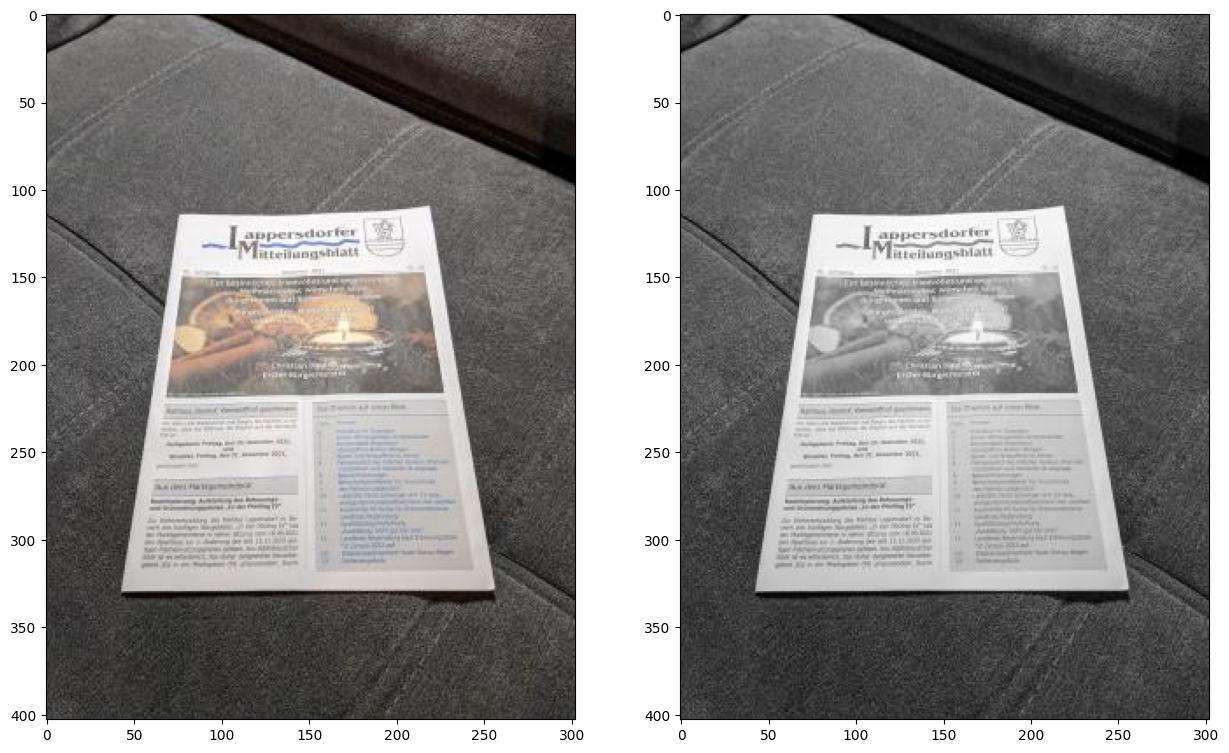

In [2]:
# Читаем изображение
img = cv2.imread('data/document.jpg')
# Переводим в оттенки серого
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)/255
rows, cols = gray.shape

# Выводим цветное и серое изображение
plt.subplot(121), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(122), plt.imshow(gray, cmap='gray')

### Harris Corner Detector
Let us now compute Harris corners. Remember that the Harris detector computes the "cornerness" score for each image pixel.

In [3]:
# Вычисляем Harris corners с помощью OpenCV
# Параметры: block size = 2, размер ядра градиента = 3, k = 0.04
cornerness = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

# Нас не интересуют рёбра, поэтому обнуляем отрицательные значения
cornerness[cornerness < 0] = 0

# Берём логарифм для удобной визуализации (очень большой диапазон значений)
cornerness = np.log(cornerness + 1e-6)

(<Axes: >, <matplotlib.image.AxesImage at 0x237e0460a90>)

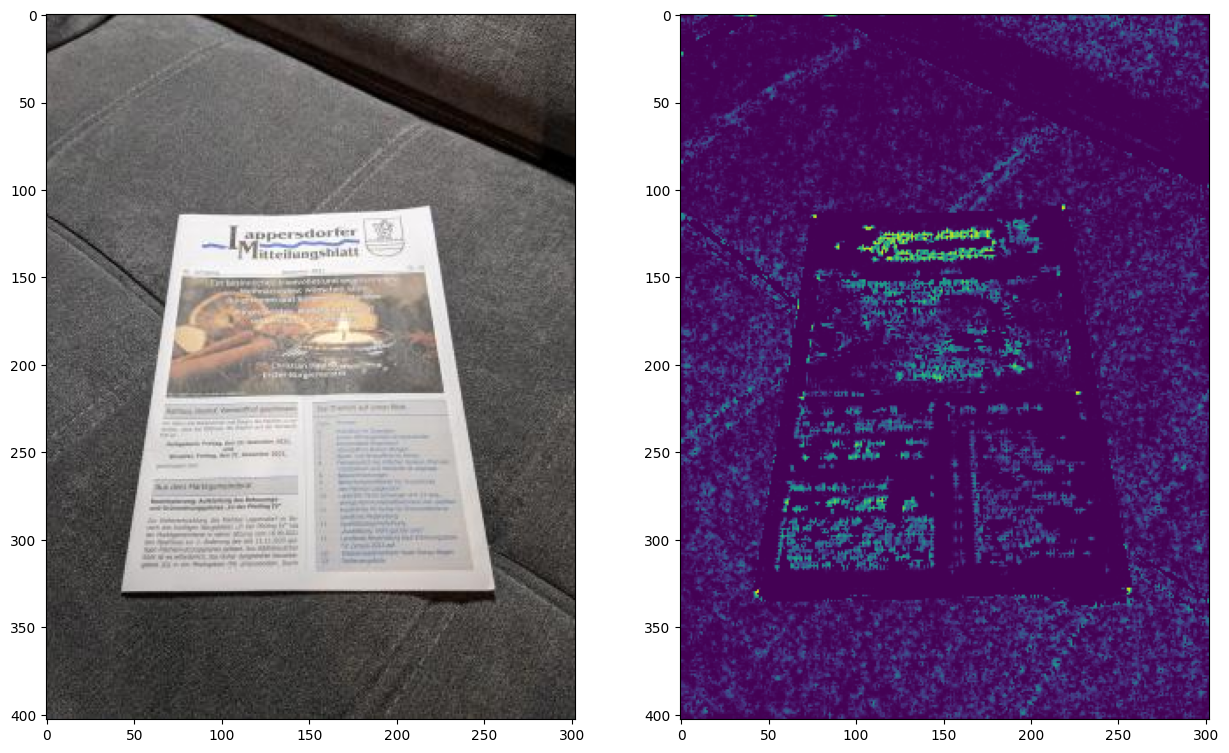

In [4]:
# Выводим изображение и карту Harris corners (в логарифмической шкале)
plt.subplot(121), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(122), plt.imshow(cornerness)

At this point, you can see that the Harris detector has detected a lot of features. Not only the four document corners, but also the corners corresponding to (black) letters printed on (white) paper. How can we filter out everything but the 4 document corners?

For that purpose, let's design a custom feature descriptor suitable to detect the document corners. In order to do so, let's have a look at the top left corner.

![Top-left corner](data/document_descriptor_example.jpg "Top-left corner")

A good descriptor of that corner, given a certain neghbouring region, would be to assess that the bottom-right quadrant is (much) brighter than the other three quadrants (i.e. top-left, top-right, bottom-left). Let's then implement it :-) I'll do the implementation for the top-left corner, you shall do the rest.

(<Axes: >, <matplotlib.image.AxesImage at 0x237e1623790>)

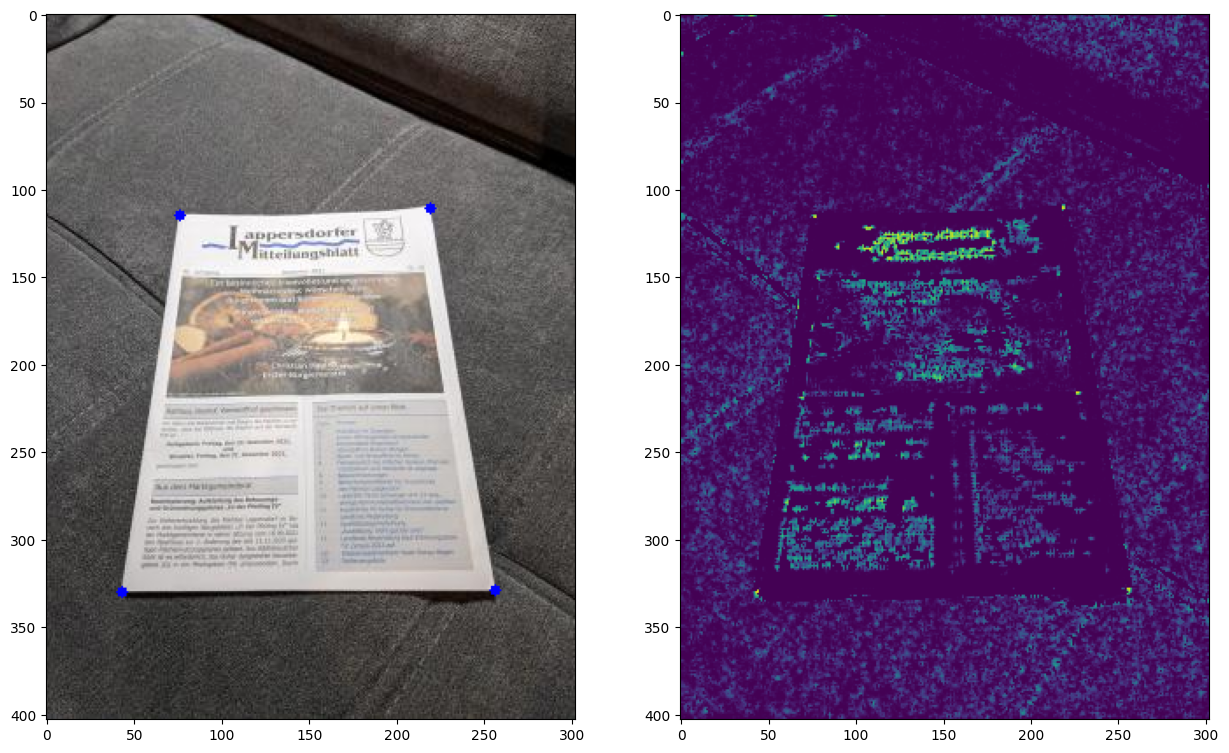

In [5]:
# Пороги для детекции
th_top_left, th_top_right = -1e6, -1e6
th_bottom_left, th_bottom_right = -1e6, -1e6

# Координаты углов
opt_top_left, opt_top_right = None, None
opt_bottom_left, opt_bottom_right = None, None

# Размер каждого квадранта (в пикселях)
quad_size = 7

# Проходим по всем пикселям с достаточным cornerness
for r in range(quad_size, rows-quad_size):
    for c in range(quad_size, cols-quad_size):
        # Отбрасываем пиксели со слишком маленьким значением cornerness
        if cornerness[r, c] < -7:
            continue
        
        # Извлекаем блок из 4 квадрантов вокруг текущего пикселя
        block = 255*gray[r-quad_size:r+quad_size+1, c-quad_size:c+quad_size+1]
        
        # Извлекаем четыре квадранта
        quad_top_left = block[0:quad_size, 0:quad_size]
        quad_top_right = block[0:quad_size, quad_size+1:2*quad_size+1]
        quad_bottom_left = block[quad_size+1:2*quad_size+1, 0:quad_size]
        quad_bottom_right = block[quad_size+1:2*quad_size+1, quad_size+1:2*quad_size+1]
        
        # Верхний левый угол документа
        # Светлая часть (бумага) — в правом нижнем квадранте,
        # остальные три квадранта — тёмный фон
        descriptor = np.mean(quad_bottom_right) - \
                     np.mean(quad_top_left) - np.mean(quad_top_right) - np.mean(quad_bottom_left)
        if descriptor > th_top_left:
            th_top_left = descriptor
            opt_top_left = (c, r)
            
        # Верхний правый угол документа
        # Светлая часть (бумага) — в левом нижнем квадранте
        descriptor = np.mean(quad_bottom_left) - \
                     np.mean(quad_top_left) - np.mean(quad_top_right) - np.mean(quad_bottom_right)
        if descriptor > th_top_right:
            th_top_right = descriptor
            opt_top_right = (c, r)
            
        # Нижний левый угол документа
        # Светлая часть (бумага) — в правом верхнем квадранте
        descriptor = np.mean(quad_top_right) - \
                     np.mean(quad_top_left) - np.mean(quad_bottom_left) - np.mean(quad_bottom_right)
        if descriptor > th_bottom_left:
            th_bottom_left = descriptor
            opt_bottom_left = (c, r)
            
        # Нижний правый угол документа
        # Светлая часть (бумага) — в левом верхнем квадранте
        descriptor = np.mean(quad_top_left) - \
                     np.mean(quad_top_right) - np.mean(quad_bottom_left) - np.mean(quad_bottom_right)
        if descriptor > th_bottom_right:
            th_bottom_right = descriptor
            opt_bottom_right = (c, r)

# Рисуем кружки в найденных углах
out = img.copy()
out = cv2.circle(out, opt_top_left, 3, (255,0,0), -1)
out = cv2.circle(out, opt_top_right, 3, (255,0,0), -1)
out = cv2.circle(out, opt_bottom_left, 3, (255,0,0), -1)
out = cv2.circle(out, opt_bottom_right, 3, (255,0,0), -1)

# Выводим результат — изображение с отмеченными углами документа
plt.subplot(121), plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.subplot(122), plt.imshow(cornerness)

### Вопросы

**Влияет ли разрешение камеры (1Mpx vs 12Mpx)? Как?**

Да, конечно влияет. Если камера 12Mpx, то картинка будет гораздо больше, и углы документа будут занимать больше пикселей. Наш `quad_size = 7` окажется слишком маленьким — область 7x7 пикселей при таком разрешении покроет совсем крошечный кусочек возле угла, и дескриптор не сможет нормально отличить бумагу от фона. А с 1Mpx камерой 7 пикселей — это уже заметная область, поэтому всё работает хорошо. Плюс при 12Mpx алгоритм будет работать намного дольше, ведь мы проходим по каждому пикселю в двойном цикле.

**Что бы я изменила в алгоритме при увеличении разрешения?**

Я бы увеличила `quad_size` пропорционально разрешению — если разрешение выросло в 3 раза, то и `quad_size` нужно увеличить примерно в 3 раза (например, до 21). Ещё можно увеличить `blockSize` в Harris детекторе. Но самый простой вариант — просто уменьшить картинку (resize) до какого-то фиксированного размера перед обработкой, тогда не нужно каждый раз подбирать параметры под разное разрешение.